In [1]:
!pip -q install transformers==4.46.3
!pip -q install accelerate
!pip -q install bitsandbytes
!pip -q install sentencepiece
!pip -q install scikit-learn
!pip -q install matplotlib
!pip -q install pandas
!pip -q install pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from transformers import (
    CLIPProcessor,
    CLIPModel,
    AutoProcessor,
    LlavaForConditionalGeneration,
    BitsAndBytesConfig
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
preferred_path = "/content/drive/MyDrive/project images/historical/preferred"
nonpreferred_path = "/content/drive/MyDrive/project images/historical/non-preferred"
market_path = "/content/drive/MyDrive/project images/new-market"

In [5]:
import os

def load_images(folder):
    image_list = []
    valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".jfif")

    for img in sorted(os.listdir(folder)):
        if img.lower().endswith(valid_extensions):
            image_list.append(os.path.join(folder, img))

    return image_list

In [6]:
preferred_images = load_images(preferred_path)
nonpreferred_images = load_images(nonpreferred_path)
market_images = load_images(market_path)

print("Preferred Images     :", len(preferred_images))
print("Non-Preferred Images :", len(nonpreferred_images))
print("Market Images        :", len(market_images))

Preferred Images     : 7
Non-Preferred Images : 8
Market Images        : 10


In [7]:
train_pref, test_pref = train_test_split(
    preferred_images,
    test_size=2,
    random_state=42,
    shuffle=True
)

print("Training Preferred :", len(train_pref))
print("Testing Preferred  :", len(test_pref))

Training Preferred : 5
Testing Preferred  : 2


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

Device : cuda


In [9]:
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_model.eval()

print("CLIP Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP Loaded Successfully


In [10]:
def get_clip_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        embedding = clip_model.get_image_features(pixel_values=inputs["pixel_values"])

    embedding = torch.nn.functional.normalize(embedding, p=2, dim=-1)

    return embedding.squeeze().cpu().numpy()

In [11]:
emb = get_clip_embedding(train_pref[0])
print("shape:", emb.shape, "| norm:", round(float(np.linalg.norm(emb)), 4))

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

shape: (512,) | norm: 1.0


In [12]:
train_embeddings = np.array([get_clip_embedding(i) for i in train_pref])
test_embeddings = np.array([get_clip_embedding(i) for i in test_pref])
nonpreferred_embeddings = np.array([get_clip_embedding(i) for i in nonpreferred_images])

print("Train Preferred    :", train_embeddings.shape)
print("Test Preferred     :", test_embeddings.shape)
print("Non-Preferred      :", nonpreferred_embeddings.shape)

Train Preferred    : (5, 512)
Test Preferred     : (2, 512)
Non-Preferred      : (8, 512)


In [13]:
print("HELD-OUT VALIDATION (want positive preference scores)")
print("=" * 55)

for i, emb in enumerate(test_embeddings):

    preferred_score = np.mean([
        cosine_similarity(emb.reshape(1, -1), t.reshape(1, -1))[0][0]
        for t in train_embeddings
    ])

    nonpreferred_score = np.mean([
        cosine_similarity(emb.reshape(1, -1), n.reshape(1, -1))[0][0]
        for n in nonpreferred_embeddings
    ])

    preference_score = preferred_score - nonpreferred_score

    print(
        f"Test Shirt {i+1}: "
        f"Preferred={preferred_score:.4f}  "
        f"Non-Preferred={nonpreferred_score:.4f}  "
        f"Preference Score={preference_score:+.4f}"
    )

HELD-OUT VALIDATION (want positive preference scores)
Test Shirt 1: Preferred=0.8620  Non-Preferred=0.6640  Preference Score=+0.1980
Test Shirt 2: Preferred=0.7792  Non-Preferred=0.6719  Preference Score=+0.1073


In [14]:
market_embeddings = {}

for img in market_images:
    market_embeddings[img] = get_clip_embedding(img)

print("Total Market Images :", len(market_embeddings))

Total Market Images : 10


In [15]:
ranking = []

for img, emb in market_embeddings.items():

    preferred_scores = [
        cosine_similarity(emb.reshape(1,-1), t.reshape(1,-1))[0][0]
        for t in train_embeddings
    ]

    nonpreferred_scores = [
        cosine_similarity(emb.reshape(1,-1), n.reshape(1,-1))[0][0]
        for n in nonpreferred_embeddings
    ]

    preferred_score    = np.mean(preferred_scores)
    nonpreferred_score = np.mean(nonpreferred_scores)
    preference_score   = preferred_score - nonpreferred_score

    ranking.append({
        "image": img,
        "preferred_score": preferred_score,
        "nonpreferred_score": nonpreferred_score,
        "preference_score": preference_score
    })

print("Scored", len(ranking), "market images")

Scored 10 market images


In [16]:
ranking = sorted(ranking, key=lambda x: x["preference_score"], reverse=True)
print("Ranking Completed")

Ranking Completed


In [17]:
print("="*80)
print("             MARKET T-SHIRT RANKING")
print("="*80)

for i, item in enumerate(ranking):
    print(f"\nRank {i+1}")
    print("Image               :", os.path.basename(item["image"]))
    print("Preferred Score     :", round(item["preferred_score"], 4))
    print("Non Preferred Score :", round(item["nonpreferred_score"], 4))
    print("Preference Score    :", round(item["preference_score"], 4))
    print("-"*60)

             MARKET T-SHIRT RANKING

Rank 1
Image               : 2.jpg
Preferred Score     : 0.8386
Non Preferred Score : 0.6538
Preference Score    : 0.1848
------------------------------------------------------------

Rank 2
Image               : 21.jpg
Preferred Score     : 0.8041
Non Preferred Score : 0.6507
Preference Score    : 0.1534
------------------------------------------------------------

Rank 3
Image               : images.jpg
Preferred Score     : 0.8387
Non Preferred Score : 0.7078
Preference Score    : 0.1309
------------------------------------------------------------

Rank 4
Image               : 1.jpg
Preferred Score     : 0.8089
Non Preferred Score : 0.6858
Preference Score    : 0.1231
------------------------------------------------------------

Rank 5
Image               : 7.jpg
Preferred Score     : 0.7641
Non Preferred Score : 0.6763
Preference Score    : 0.0877
------------------------------------------------------------

Rank 6
Image               : images2.

In [18]:
top2 = ranking[:2]

print("TOP-2 RECOMMENDATIONS")
print("="*40)
for item in top2:
    print(os.path.basename(item["image"]), "| score:", round(item["preference_score"], 4))

TOP-2 RECOMMENDATIONS
2.jpg | score: 0.1848
21.jpg | score: 0.1534


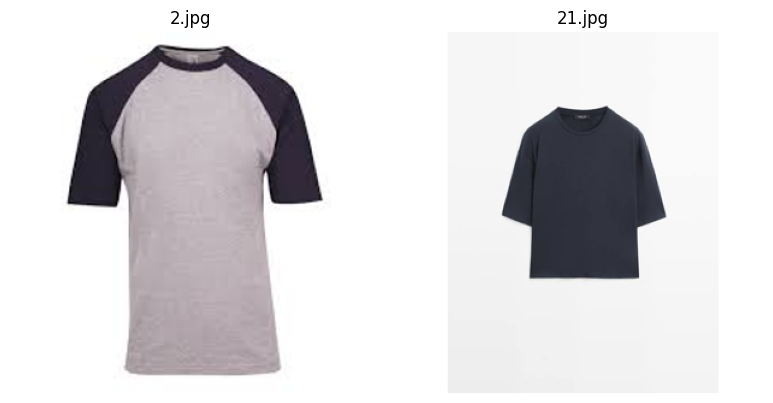

In [20]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, item in enumerate(top2):
    img = Image.open(item["image"])
    img = ImageOps.pad(img, (300, 300), color="white")

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(os.path.basename(item["image"]))

plt.tight_layout()
plt.show()

In [21]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(
    "llava-hf/llava-1.5-7b-hf"
)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to(device)

llava_model.eval()

print("LLaVA Loaded Successfully!")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA Loaded Successfully!


In [24]:
from PIL import Image

def explain_tshirt(image_path):

    image = Image.open(image_path).convert("RGB")

    prompt = (
        "USER: <image>\n"
        "This T-shirt has been recommended to a user based on previous preferences. "
        "Describe the T-shirt and explain which visual characteristics "
        "such as color, pattern, design, style, or graphics may have "
        "contributed to this recommendation.\n"
        "ASSISTANT:"
    )

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output = llava_model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False
        )

    response = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return response





In [27]:
for i, item in enumerate(top2):

    print("=" * 80)
    print(f"Recommendation {i+1}")
    print(os.path.basename(item["image"]))
    print(f"Preference Score : {item['preference_score']:.4f}")
    print(f"Preferred Score  : {item['preferred_score']:.4f}")
    print(f"Non-Preferred Score : {item['nonpreferred_score']:.4f}")
    print("=" * 80)

    explanation = explain_tshirt(item["image"])

    print(explanation)
    print()

Recommendation 1
2.jpg
Preference Score : 0.1848
Preferred Score  : 0.8386
Non-Preferred Score : 0.6538


Expanding inputs for image tokens in LLaVa should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will throw an error in v4.47.


USER:  
This T-shirt has been recommended to a user based on previous preferences. Describe the T-shirt and explain which visual characteristics such as color, pattern, design, style, or graphics may have contributed to this recommendation.
ASSISTANT: The T-shirt in the image is a gray and blue striped shirt with a collared design. The blue and gray stripes create a visually appealing contrast, making the shirt stand out. The collared design adds a touch of formality to the casual T-shirt, making it suitable for various occasions. The combination of these elements may have contributed to the recommendation, as it offers a stylish and versatile option for the user.

Recommendation 2
21.jpg
Preference Score : 0.1534
Preferred Score  : 0.8041
Non-Preferred Score : 0.6507
USER:  
This T-shirt has been recommended to a user based on previous preferences. Describe the T-shirt and explain which visual characteristics such as color, pattern, design, style, or graphics may have contributed to t